1.指定斜率与截距（如k=2、b=5）绘制直线L0，然后在直线上随机采样50个点（真值X0）；根据50个真值点生成噪声服从正态分布（如均值为0、方差为2）的样本（Xn）。\
（1）利用最小二乘算法拟合50个样本点，生成拟合直线L1。\
（2）利用Scikit-learn线性回归库拟合50个样本点，生成拟合直线L2。\
（3）将X0、Xn、L0、L1与L2绘制在一起以比较最小二乘法与Scikit-learn线性回归库之间的差异。


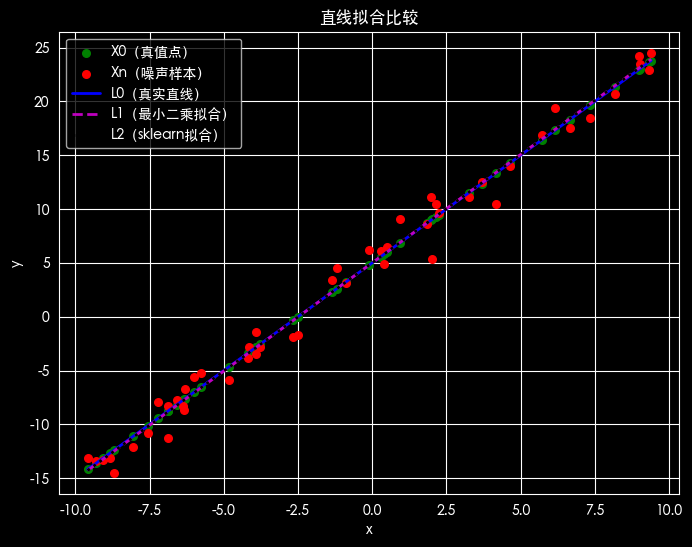

===== 第1题运行结果 =====
L0: y = 2x + 5
L1（最小二乘）: y = 2.012304x + 5.009141
L2（sklearn） : y = 2.012304x + 5.009141


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_moons
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import matplotlib

# 自动寻找系统中的中文字体
font = matplotlib.font_manager.FontProperties(fname="/System/Library/Fonts/STHeiti Light.ttc")

plt.rcParams['font.family'] = font.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 固定随机种子，保证结果可复现
np.random.seed(42)

# =========================
# 1. 直线采样与拟合
# =========================
k, b = 2, 5   # 指定真值直线 L0: y = 2x + 5

# 在区间[-10, 10]内随机采样50个x
x0 = np.sort(np.random.uniform(-10, 10, 50))
y0 = k * x0 + b   # 真值点 X0

# 加入高斯噪声 N(0, 2)，这里题目中的“方差为2”，所以标准差为 sqrt(2)
noise = np.random.normal(0, np.sqrt(2), 50)
yn = y0 + noise   # 噪声样本 Xn

# （1）最小二乘法拟合
A = np.vstack([x0, np.ones(len(x0))]).T
k1, b1 = np.linalg.lstsq(A, yn, rcond=None)[0]

# （2）Scikit-learn 线性回归拟合
lr1 = LinearRegression()
lr1.fit(x0.reshape(-1, 1), yn)
k2 = lr1.coef_[0]
b2 = lr1.intercept_

# 构造拟合直线
x_line = np.linspace(x0.min(), x0.max(), 200)
y_line0 = k * x_line + b
y_line1 = k1 * x_line + b1
y_line2 = k2 * x_line + b2

# （3）绘图比较
plt.figure(figsize=(8, 6))
plt.scatter(x0, y0, color='green', label='X0（真值点）', s=30)
plt.scatter(x0, yn, color='red', label='Xn（噪声样本）', s=30)
plt.plot(x_line, y_line0, 'b-', linewidth=2, label='L0（真实直线）')
plt.plot(x_line, y_line1, 'm--', linewidth=2, label='L1（最小二乘拟合）')
plt.plot(x_line, y_line2, 'k:', linewidth=2, label='L2（sklearn拟合）')
plt.xlabel('x')
plt.ylabel('y')
plt.title('直线拟合比较')
plt.legend()
plt.grid(True)
plt.show()

print("===== 第1题运行结果 =====")
print(f"L0: y = {k}x + {b}")
print(f"L1（最小二乘）: y = {k1:.6f}x + {b1:.6f}")
print(f"L2（sklearn） : y = {k2:.6f}x + {b2:.6f}")

2.通过以下方式导入make_moons二维数据：\
from sklearn.datasets import make_moons\
x,y=make_moons(50,noise=0.3) #指定50个噪声值为0.3的二维样本。\
（1）采用两种不同的颜色绘制两类数据点。\
（2）将二维数据进行线性拟合以求取以下表达式中的各参数值。\
Y=W_1∙X_1+W_2∙X_2+W_0\
3.]画图比较真实y与拟合fitted_y之间的差异。


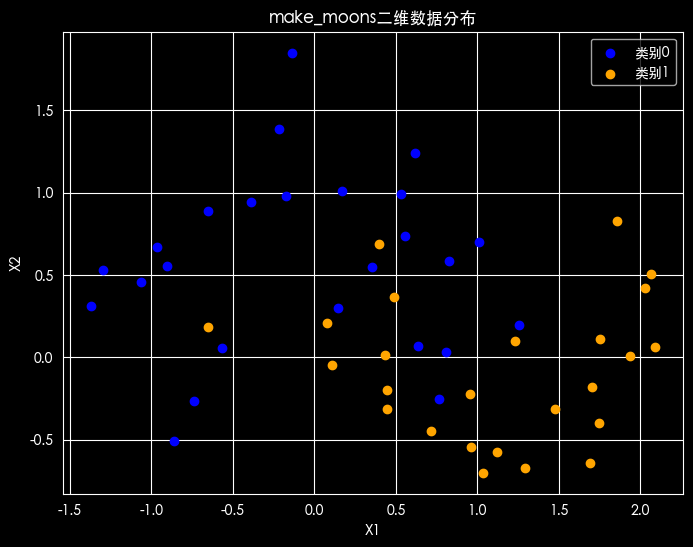

===== 第2题运行结果 =====
W1 = 0.258794
W2 = -0.343354
W0 = 0.450988
线性拟合表达式：Y = 0.258794*X1 + -0.343354*X2 + 0.450988
MSE = 0.120673
R^2 = 0.517309


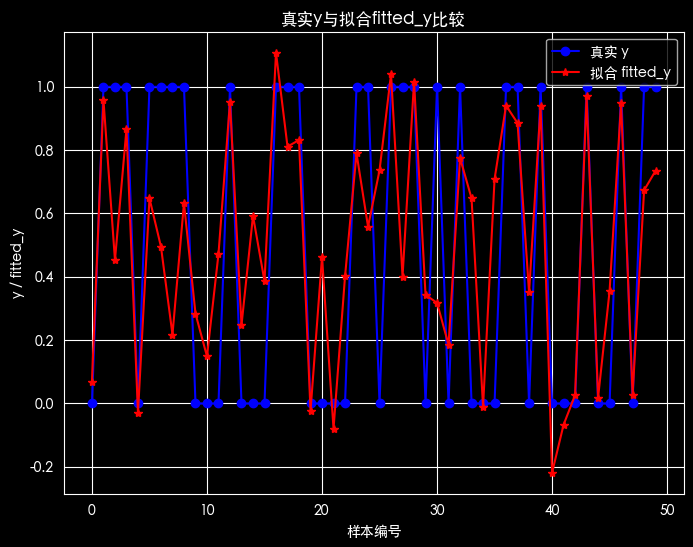

In [3]:
# =========================
# 2. make_moons二维数据
# =========================
x, y = make_moons(50, noise=0.3, random_state=42)

# （1）采用两种不同颜色绘制两类数据点
plt.figure(figsize=(8, 6))
plt.scatter(x[y == 0, 0], x[y == 0, 1], color='blue', label='类别0')
plt.scatter(x[y == 1, 0], x[y == 1, 1], color='orange', label='类别1')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('make_moons二维数据分布')
plt.legend()
plt.grid(True)
plt.show()

# （2）线性拟合
# Y = W1*X1 + W2*X2 + W0
lr2 = LinearRegression()
lr2.fit(x, y)

W1 = lr2.coef_[0]
W2 = lr2.coef_[1]
W0 = lr2.intercept_

fitted_y = lr2.predict(x)

print("===== 第2题运行结果 =====")
print(f"W1 = {W1:.6f}")
print(f"W2 = {W2:.6f}")
print(f"W0 = {W0:.6f}")
print(f"线性拟合表达式：Y = {W1:.6f}*X1 + {W2:.6f}*X2 + {W0:.6f}")
print(f"MSE = {mean_squared_error(y, fitted_y):.6f}")
print(f"R^2 = {r2_score(y, fitted_y):.6f}")

# （3）画图比较真实y与拟合fitted_y
plt.figure(figsize=(8, 6))
plt.plot(range(len(y)), y, 'bo-', label='真实 y')
plt.plot(range(len(fitted_y)), fitted_y, 'r*-', label='拟合 fitted_y')
plt.xlabel('样本编号')
plt.ylabel('y / fitted_y')
plt.title('真实y与拟合fitted_y比较')
plt.legend()
plt.grid(True)
plt.show()

房价一直以来是一个很火的话题，现在有如下居住面积（平方英尺）与房价（美元）对应关系数据，从中可以大致看出房价与居住面积具有一定线性关系。为了简单起见，这里理想化地假设房价只与居住面积有关，那么怎么在现有数据的基础上求出数据模型以及预测房价呢？

===== 第3题运行结果 =====
房价预测模型：Price = 87.001097 * Area + 52217.377241
训练集 MSE = 57982596.890116
训练集 R^2 = 0.957957
测试集 MSE = 9327157.201906
测试集 R^2 = 0.988981

测试样本预测结果：
样本1: 面积=1592, 真实房价=187120, 预测房价=190723.12
样本2: 面积=1188, 真实房价=151099, 预测房价=155574.68
样本3: 面积=1888, 真实房价=215315, 预测房价=216475.45
样本4: 面积=1429, 真实房价=178927, 预测房价=176541.94
样本5: 面积=940, 真实房价=131432, 预测房价=133998.41


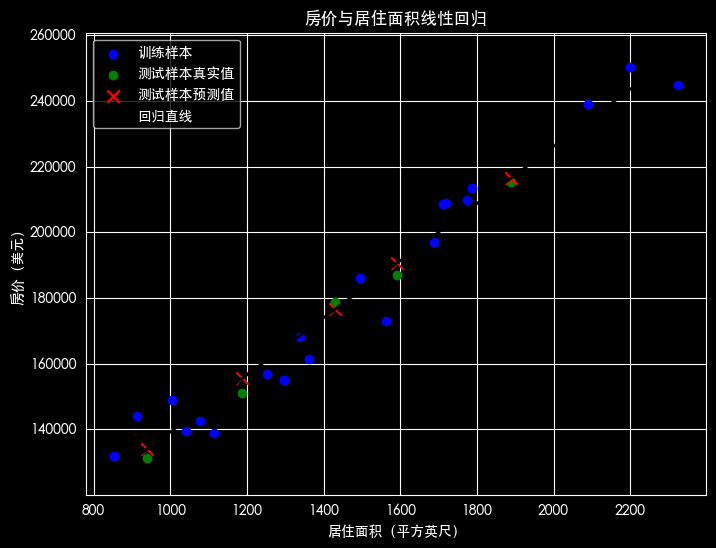

In [4]:
# =========================
# 3. 房价预测
# =========================
area_train = np.array([
    1710, 1362, 1786, 1719, 2198, 1562, 1689, 2090, 1774, 1077,
    1040, 2324, 912, 1494, 1253, 854, 1004, 1296, 1114, 1339
], dtype=float)

price_train = np.array([
    208500, 161500, 213500, 209000, 250310, 173000, 197000, 239000, 209900, 142600,
    139500, 245000, 144000, 186119, 157000, 132000, 149000, 155190, 139000, 168200
], dtype=float)

area_test = np.array([1592, 1188, 1888, 1429, 940], dtype=float)
price_test = np.array([187120, 151099, 215315, 178927, 131432], dtype=float)

house_model = LinearRegression()
house_model.fit(area_train.reshape(-1, 1), price_train)

w_house = house_model.coef_[0]
b_house = house_model.intercept_

pred_train = house_model.predict(area_train.reshape(-1, 1))
pred_test = house_model.predict(area_test.reshape(-1, 1))

print("===== 第3题运行结果 =====")
print(f"房价预测模型：Price = {w_house:.6f} * Area + {b_house:.6f}")
print(f"训练集 MSE = {mean_squared_error(price_train, pred_train):.6f}")
print(f"训练集 R^2 = {r2_score(price_train, pred_train):.6f}")
print(f"测试集 MSE = {mean_squared_error(price_test, pred_test):.6f}")
print(f"测试集 R^2 = {r2_score(price_test, pred_test):.6f}")

print("\n测试样本预测结果：")
for i in range(len(area_test)):
    print(f"样本{i+1}: 面积={area_test[i]:.0f}, 真实房价={price_test[i]:.0f}, 预测房价={pred_test[i]:.2f}")

# 绘图
plt.figure(figsize=(8, 6))
plt.scatter(area_train, price_train, color='blue', label='训练样本')
plt.scatter(area_test, price_test, color='green', label='测试样本真实值')
plt.scatter(area_test, pred_test, color='red', marker='x', s=80, label='测试样本预测值')

x_line = np.linspace(area_train.min(), area_train.max(), 200)
y_line = house_model.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='black', linewidth=2, label='回归直线')

plt.xlabel('居住面积（平方英尺）')
plt.ylabel('房价（美元）')
plt.title('房价与居住面积线性回归')
plt.legend()
plt.grid(True)
plt.show()

任何事情都有一个标准，体重也一样，超标或者不达标都可能是身体某些地方有问题。影响体重的因素往往有多种，体内的激素水平、饮食的情况、心情的原因等等都可以影响体重，假设身高影响因素最大，通过构建回归模型用身高来预测体重。

===== 第4题运行结果 =====
体重预测模型：Weight = 61.115338 * Height + -44.887772
训练集 MSE = 13.001879
训练集 R^2 = 0.971122
测试集 MSE = 25.880485
测试集 R^2 = 0.937308

测试样本预测结果：
样本1: 身高=0.83, 真实体重=11, 预测体重=5.84
样本2: 身高=1.08, 真实体重=17, 预测体重=21.12
样本3: 身高=1.26, 真实体重=27, 预测体重=32.12
样本4: 身高=1.51, 真实体重=41, 预测体重=47.40
样本5: 身高=1.60, 真实体重=50, 预测体重=52.90
样本6: 身高=1.67, 真实体重=64, 预测体重=57.17
样本7: 身高=1.75, 真实体重=66, 预测体重=62.06


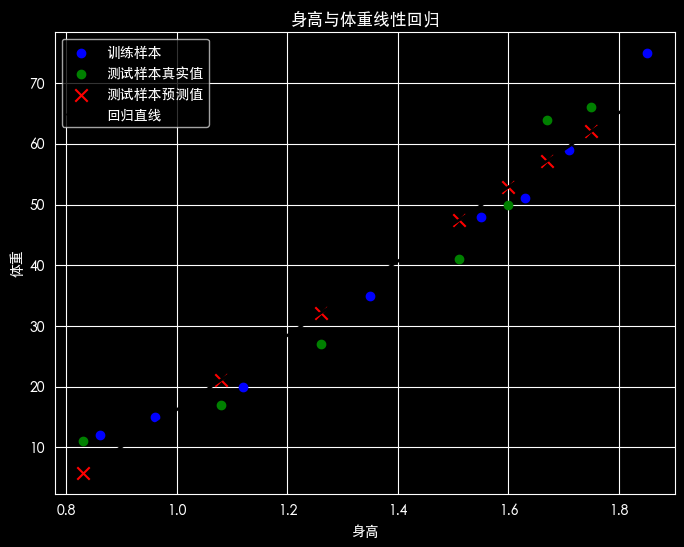

In [5]:
# =========================
# 4. 身高预测体重
# =========================
height_train = np.array([0.86, 0.96, 1.12, 1.35, 1.55, 1.63, 1.71, 1.85], dtype=float)
weight_train = np.array([12, 15, 20, 35, 48, 51, 59, 75], dtype=float)

height_test = np.array([0.83, 1.08, 1.26, 1.51, 1.60, 1.67, 1.75], dtype=float)
weight_test = np.array([11, 17, 27, 41, 50, 64, 66], dtype=float)

body_model = LinearRegression()
body_model.fit(height_train.reshape(-1, 1), weight_train)

w_body = body_model.coef_[0]
b_body = body_model.intercept_

pred_body_train = body_model.predict(height_train.reshape(-1, 1))
pred_body_test = body_model.predict(height_test.reshape(-1, 1))

print("===== 第4题运行结果 =====")
print(f"体重预测模型：Weight = {w_body:.6f} * Height + {b_body:.6f}")
print(f"训练集 MSE = {mean_squared_error(weight_train, pred_body_train):.6f}")
print(f"训练集 R^2 = {r2_score(weight_train, pred_body_train):.6f}")
print(f"测试集 MSE = {mean_squared_error(weight_test, pred_body_test):.6f}")
print(f"测试集 R^2 = {r2_score(weight_test, pred_body_test):.6f}")

print("\n测试样本预测结果：")
for i in range(len(height_test)):
    print(f"样本{i+1}: 身高={height_test[i]:.2f}, 真实体重={weight_test[i]:.0f}, 预测体重={pred_body_test[i]:.2f}")

# 绘图
plt.figure(figsize=(8, 6))
plt.scatter(height_train, weight_train, color='blue', label='训练样本')
plt.scatter(height_test, weight_test, color='green', label='测试样本真实值')
plt.scatter(height_test, pred_body_test, color='red', marker='x', s=80, label='测试样本预测值')

x_line = np.linspace(height_train.min(), height_train.max(), 200)
y_line = body_model.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='black', linewidth=2, label='回归直线')

plt.xlabel('身高')
plt.ylabel('体重')
plt.title('身高与体重线性回归')
plt.legend()
plt.grid(True)
plt.show()